# 3- Exploring some of the features to be used

- Fixations: count, duration (mean/std/max/min)
- Saccades: count, peak_veocity, amplitude (mean/max/min/std), duration (mean/std/max/min)
- Blinks: count, mean duration
- Pupil: LHIPA 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
import cognitive_models.interpolate as cwinterp
import cognitive_models.pupil_utils as cwpupil
from importlib import reload
reload(cwpupil)
reload(cwinterp)
reload(cwpre)
reload(cwfeat)

COLET_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "COLET_CSV"
PARTICIPANTS = list(range(1, 48)) # Participants 1 to 10
PARTICIPANTS.remove(6) # Bad data
EXPERIMENTS = [1,2,3,4]

### A. Getting all the needed features

In [2]:
# 1- Load all required data
all_eye_data = cwpre.load_colet_data(COLET_DATASET_DIR, PARTICIPANTS, EXPERIMENTS)

print(f"Loaded eye-tracking data for {len(PARTICIPANTS)} participants and {len(EXPERIMENTS)} experiments. Total records: {len(all_eye_data)}")

There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4099 records at 120 Hz
Final merged and resampled dataset has 2028 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 3437 records at 120 Hz
Final merged and resampled dataset has 1709 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 8754 records at 120 Hz
Final merged and resampled dataset has 4285 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 4637 records at 120 Hz
Final merged and resampled dataset has 2290 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 5082 records at 120 Hz
Final merged and resampled dataset has 2505 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 3557 records at 120 Hz
Final merged and resampled dataset has 1769 records at 60 Hz
Ther

In [3]:
# Lets check integrity of the data
display(all_eye_data.columns)
all_eye_data.groupby(['subject_id', 'task_id'])['cl_class'].value_counts().sort_index().head()

Index(['timestamp_sec', 'eye_id', 'pupil_diameter_px', 'confidence',
       'norm_pos_x', 'norm_pos_y', 'gaze_point_3d_x', 'gaze_point_3d_y',
       'gaze_point_3d_z', 'subject_id', 'task_id', 'cl_class'],
      dtype='str')

subject_id  task_id  cl_class
1           1        low         2028
            2        medium      1709
            3        high        4285
            4        medium      2290
2           1        low         2505
Name: count, dtype: int64

In [40]:
import tqdm

reload(cwfeat)
all_eye_data_grouped = all_eye_data.groupby(['subject_id', 'task_id'])
# Extract all window features
Fs = 60
WINDOW_N = 500 # 5 seconds at 60Hz
WINDOW_STEP = 100
SKIP_EDGE_SAMPLES = Fs # first & last second are discarded

n_skipped_windows = 0

features_df = pd.DataFrame()
for (subject_id, task_id), group_df in tqdm.tqdm(all_eye_data_grouped, desc="Extracting features"):
    feature_rows = []
    # Discard edge samples
    group_df = group_df.iloc[SKIP_EDGE_SAMPLES:-SKIP_EDGE_SAMPLES].sort_values('timestamp_sec')
    
    # Extract features in sliding windows
    for start in range(WINDOW_N, len(group_df), WINDOW_STEP):
        window_df = group_df.iloc[start - WINDOW_N:start].reset_index(drop=True)
        window_preprocess_df, window_gaze_df, window_pupil_df, window_gaps_df = cwpre.preprocess_colet_data(window_df, verbose=False)
        if window_preprocess_df['low_confidence_percentage'].iloc[0] > 30:
            t_start = window_preprocess_df['timestamp_sec'].min()
            t_end = window_preprocess_df['timestamp_sec'].max()
            #print(f"Skipping window [{t_start:.2f}, {t_end:.2f}] due to low confidence percentage of {window_preprocess_df['low_confidence_percentage'].iloc[0]:.2f}%")
            n_skipped_windows += 1
            continue

        # Extract features
        try:
            features = cwfeat.extract_window_features(
                window_preprocess_df, 
                window_gaze_df, 
                window_pupil_df, 
                window_gaps_df, 
                ivt_threshold=45, 
                min_fixation_duration=55, 
                verbose=False
            )
        except Exception as e:
            print(f"Error extracting features for window in subject {subject_id}, task {task_id}: {e}")
            continue
        features['bad_samples_ratio'] = window_preprocess_df['low_confidence_percentage'].mean()
        features['subject_id'] = subject_id
        features['task_id'] = task_id
        features['cl_class'] = window_df['cl_class'].iloc[0] # Class is the same for a given task
        feature_rows.append(features)
    
    features_df = pd.concat([features_df, pd.DataFrame(feature_rows)], ignore_index=True)

print(f"Extracted features for {len(features_df)} windows.")
print(f"Skipped {n_skipped_windows} windows due to low confidence percentage.")

Extracting features:  13%|█▎        | 24/184 [00:55<04:19,  1.62s/it]

Extracting features:  28%|██▊       | 51/184 [02:21<10:17,  4.64s/it]

Extracting features:  34%|███▍      | 63/184 [02:55<04:19,  2.15s/it]

Extracting features:  43%|████▎     | 79/184 [03:36<07:09,  4.09s/it]

Extracting features:  60%|█████▉    | 110/184 [05:02<02:32,  2.07s/it]

Extracting features: 100%|██████████| 184/184 [08:41<00:00,  2.83s/it]

Extracted features for 3980 windows.
Skipped 368 windows due to low confidence percentage.


In [41]:
# Check what is the issue with the NaNs
display(features_df[features_df.isna().any(axis=1)].head())
print(f"Dropping {features_df.isna().any(axis=1).sum()} rows with NaN values.")
features_df_transformed = features_df.copy()
features_df_transformed.dropna(inplace=True)

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_std,saccades_count,saccades_peak_velocity_mean,saccades_amplitude_mean,saccades_amplitude_max,saccades_amplitude_min,...,saccades_duration_min,saccades_duration_std,blinks_count,blinks_duration_mean,pupil_lhipa,pupil_ripa2,bad_samples_ratio,subject_id,task_id,cl_class
429,12,584.839167,3700.74,83.35,1009.188146,12,153.100660,3.057922,8.659043,0.029674,...,33.34,53.880395,13,0.176958,NaN,0.000790,29.4,7,4,medium
1123,10,471.761000,1983.73,116.69,577.468413,9,123.825199,1.079399,3.103185,0.019027,...,16.67,30.052270,12,0.159754,NaN,0.001241,29.2,14,4,medium
1393,8,537.607500,1116.89,50.01,389.802105,7,127.022534,2.730308,7.064138,0.226833,...,33.34,40.670636,12,0.165311,NaN,0.001841,28.4,17,4,medium
1727,6,1111.333333,4084.15,233.38,1474.128267,6,270.168923,4.743220,13.816370,1.246461,...,33.34,40.031146,17,0.162778,NaN,NaN,27.0,21,4,high
1728,7,1069.261429,4150.83,233.38,1388.369453,6,177.975175,4.904809,13.591585,1.246461,...,33.34,40.376745,16,0.159407,NaN,0.000873,23.8,21,4,high


Dropping 6 rows with NaN values.


Let's check the distribtuion of the label classes 

<Axes: title={'center': 'Distribution of classes'}, xlabel='Cognitive Load Class', ylabel='Number of windows'>

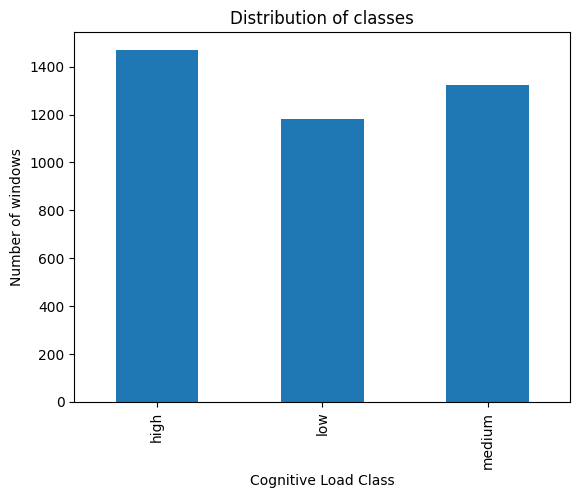

In [42]:
features_df_transformed.groupby('cl_class').count().plot(kind='bar', y='subject_id', title="Distribution of classes", legend=False, ylabel="Number of windows", xlabel="Cognitive Load Class")

As one can see, classes look quite balanced, which is a good thing for training a classifier

subject_id    32
dtype: int64

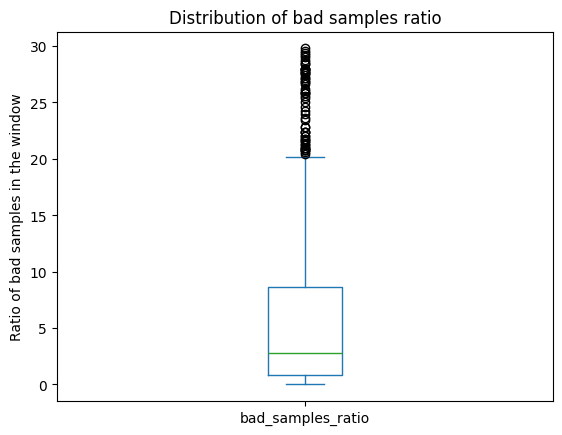

In [28]:
# Bad samples
# features_df_transformed.plot(kind='hist', y='bad_samples_ratio', bins=50, title="Distribution of bad samples ratio", xlabel="Ratio of bad samples in the window", ylabel="Count of windows")
features_df_transformed.plot(kind='box', y='bad_samples_ratio', title="Distribution of bad samples ratio", ylabel="Ratio of bad samples in the window")
features_df_transformed.loc[features_df_transformed['bad_samples_ratio'] > 25, ['subject_id']].count()

Now let's explore the distribution of the LHIPA metric.

As a reminder, it is related to a count of the number of spike/sec over the defined time window

In [97]:
features_df_transformed['pupil_lhipa'].describe()

count    913.000000
mean       4.672975
std        0.369081
min        3.287014
25%        4.460947
50%        4.695734
75%        4.930521
max        5.634881
Name: pupil_lhipa, dtype: float64

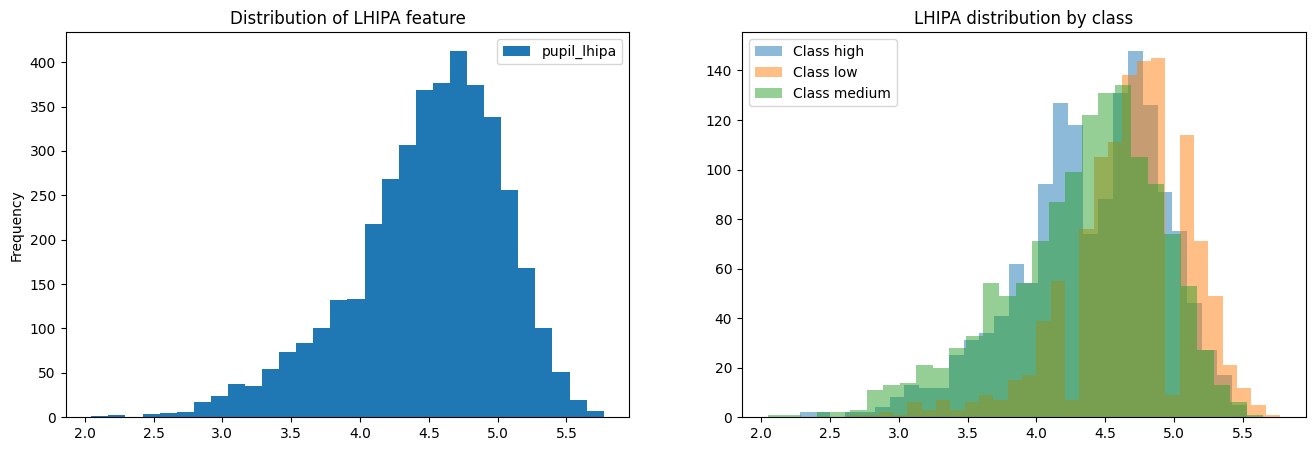

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
features_df_transformed.plot(y='pupil_lhipa', kind='hist', bins=30, title='Distribution of LHIPA feature', ax=axs[0])
grouped_df = features_df_transformed.groupby('cl_class')
for cl_class, group in grouped_df:
    axs[1].hist(group['pupil_lhipa'], bins=30, alpha=0.5, label=f'Class {cl_class}')
axs[1].set_title('LHIPA distribution by class')
axs[1].legend()

<Axes: title={'center': 'pupil_lhipa'}, xlabel='Cognitive Load Class', ylabel='LHIPA'>

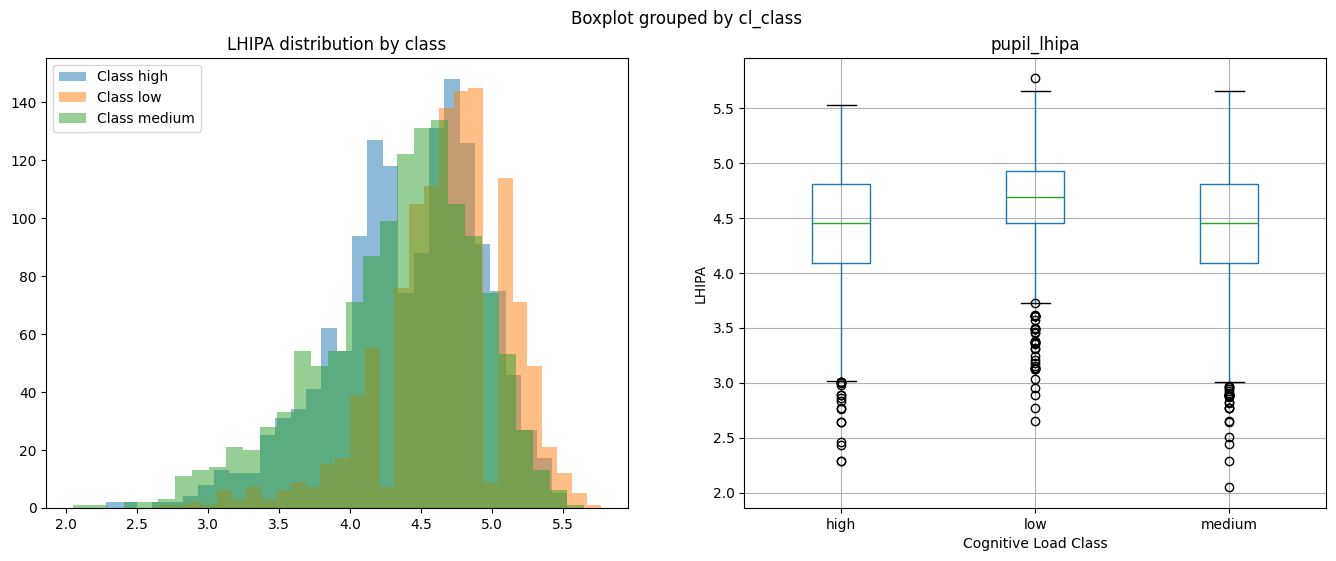

In [44]:
# Have box plots for the 3 classes on the same plot (x axis is class, y axis is LHIPA)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
grouped_df = features_df_transformed.groupby('cl_class')
for cl_class, group in grouped_df:
    axs[0].hist(group['pupil_lhipa'], bins=30, alpha=0.5, label=f'Class {cl_class}')
axs[0].legend()
axs[0].set_title('LHIPA distribution by class')
features_df_transformed.boxplot(column='pupil_lhipa', by='cl_class', ax=axs[1], ylabel='LHIPA', xlabel='Cognitive Load Class')


In [45]:
# Lets perform a ttest to see if the difference in LHIPA between classes is significant
from scipy.stats import ttest_ind
class_0 = features_df_transformed[features_df_transformed['cl_class'] == 'low']['pupil_lhipa']
class_1 = features_df_transformed[features_df_transformed['cl_class'] == 'medium']['pupil_lhipa']
class_2 = features_df_transformed[features_df_transformed['cl_class'] == 'high']['pupil_lhipa']
print(f"Number of windows in low class: {len(class_0)}, medium class: {len(class_1)}, high class: {len(class_2)}")
t_stat, p_value = ttest_ind(class_0, class_1, equal_var=False)
print(f"T-test between low and medium classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_0, class_2, equal_var=False)
print(f"T-test between low and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_1, class_2, equal_var=False)
print(f"T-test between medium and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")

Number of windows in low class: 1180, medium class: 1323, high class: 1471
T-test between low and medium classes: t-statistic=14.680, p-value=0.00000
T-test between low and high classes: t-statistic=14.792, p-value=0.00000
T-test between medium and high classes: t-statistic=-0.958, p-value=0.33807


Let's take a look at the Cohen's d effect size metric.

It tells you how much is the mean difference between two distributions in terms of std multiplier.
For example, if $C_d\approx 0.5$, then it means that the two distribution means are different at a scale of 0.5 the std.

| $C_d$ coeff | effect size |
|-------------|-------------|
| 0.2 | small
| 0.5 | Medium
| 0.8 | Large

In [46]:
# Cohen's d effect size
def cohen_d(x, y):
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(y) - np.mean(x)) / pooled_std if pooled_std > 0 else 0

d_low_medium = cohen_d(class_0, class_1)
d_low_high = cohen_d(class_0, class_2)
d_medium_high = cohen_d(class_1, class_2)
print(f"Cohen's d effect size between low and medium classes: {d_low_medium:.3f}")
print(f"Cohen's d effect size between low and high classes: {d_low_high:.3f}")
print(f"Cohen's d effect size between medium and high classes: {d_medium_high:.3f}")


Cohen's d effect size between low and medium classes: -0.579
Cohen's d effect size between low and high classes: -0.567
Cohen's d effect size between medium and high classes: 0.036


#### What about this new RIPA2 "real-time" pupil frequency metric

In [47]:
features_df_transformed['pupil_ripa2'].describe()

count    3974.000000
mean        0.004187
std         0.004089
min         0.000269
25%         0.001862
50%         0.003237
75%         0.005213
max         0.065794
Name: pupil_ripa2, dtype: float64

<Axes: title={'center': 'pupil_ripa2'}, xlabel='Cognitive Load Class', ylabel='RIPA2'>

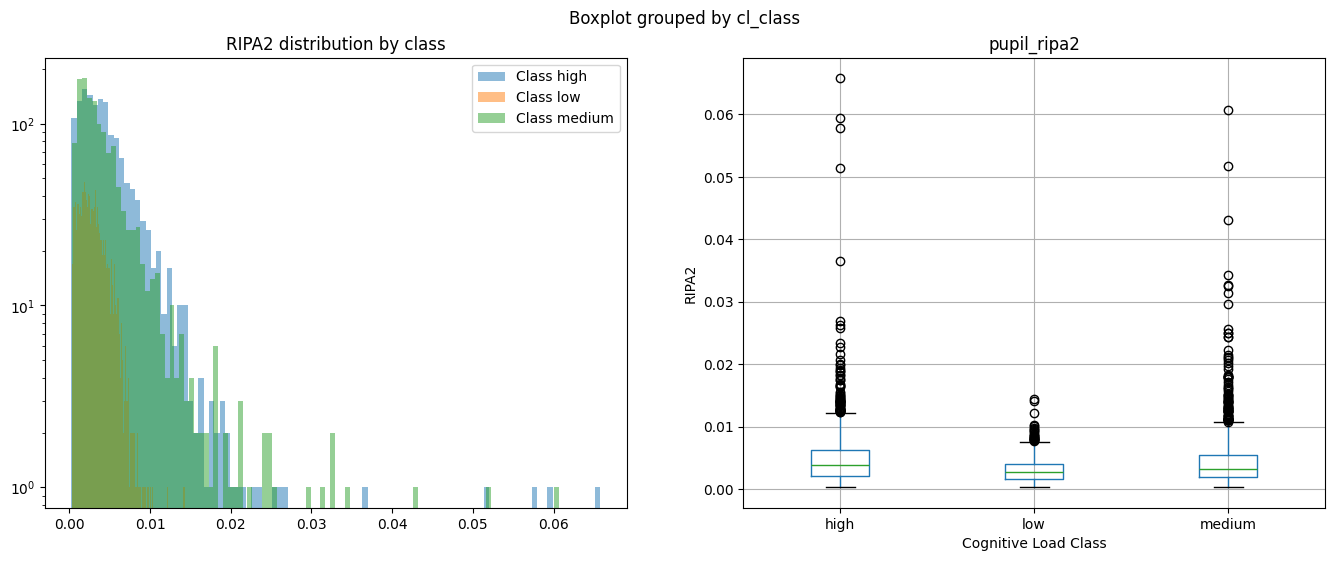

In [48]:
# Have box plots for the 3 classes on the same plot (x axis is class, y axis is LHIPA)
fig, axs = plt.subplots(1, 2, figsize=(16, 6))
grouped_df = features_df.groupby('cl_class')
for cl_class, group in grouped_df:
    x = group['pupil_ripa2']
    axs[0].hist(x, bins=100, alpha=0.5, label=f'Class {cl_class}', log=True)
axs[0].legend()
axs[0].set_title('RIPA2 distribution by class')
features_df.boxplot(column='pupil_ripa2', by='cl_class', ax=axs[1], ylabel='RIPA2', xlabel='Cognitive Load Class')


In [49]:
class_0 = features_df_transformed[features_df_transformed['cl_class'] == 'low']['pupil_ripa2']
class_1 = features_df_transformed[features_df_transformed['cl_class'] == 'medium']['pupil_ripa2']
class_2 = features_df_transformed[features_df_transformed['cl_class'] == 'high']['pupil_ripa2']

print(f"Number of windows in low class: {len(class_0)}, medium class: {len(class_1)}, high class: {len(class_2)}")
t_stat, p_value = ttest_ind(class_0, class_1, equal_var=False)
print(f"T-test between low and medium classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_0, class_2, equal_var=False)
print(f"T-test between low and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
t_stat, p_value = ttest_ind(class_1, class_2, equal_var=False)
print(f"T-test between medium and high classes: t-statistic={t_stat:.3f}, p-value={p_value:.5f}")
d_low_medium = cohen_d(class_0, class_1)
d_low_high = cohen_d(class_0, class_2)
d_medium_high = cohen_d(class_1, class_2)
print(f"Cohen's d effect size between low and medium classes: {d_low_medium:.3f}")
print(f"Cohen's d effect size between low and high classes: {d_low_high:.3f}")
print(f"Cohen's d effect size between medium and high classes: {d_medium_high:.3f}")

Number of windows in low class: 1180, medium class: 1323, high class: 1471
T-test between low and medium classes: t-statistic=-10.597, p-value=0.00000
T-test between low and high classes: t-statistic=-13.906, p-value=0.00000
T-test between medium and high classes: t-statistic=-2.230, p-value=0.02584
Cohen's d effect size between low and medium classes: 0.407
Cohen's d effect size between low and high classes: 0.502
Cohen's d effect size between medium and high classes: 0.084


#### What about the distributions of the fixations metric?

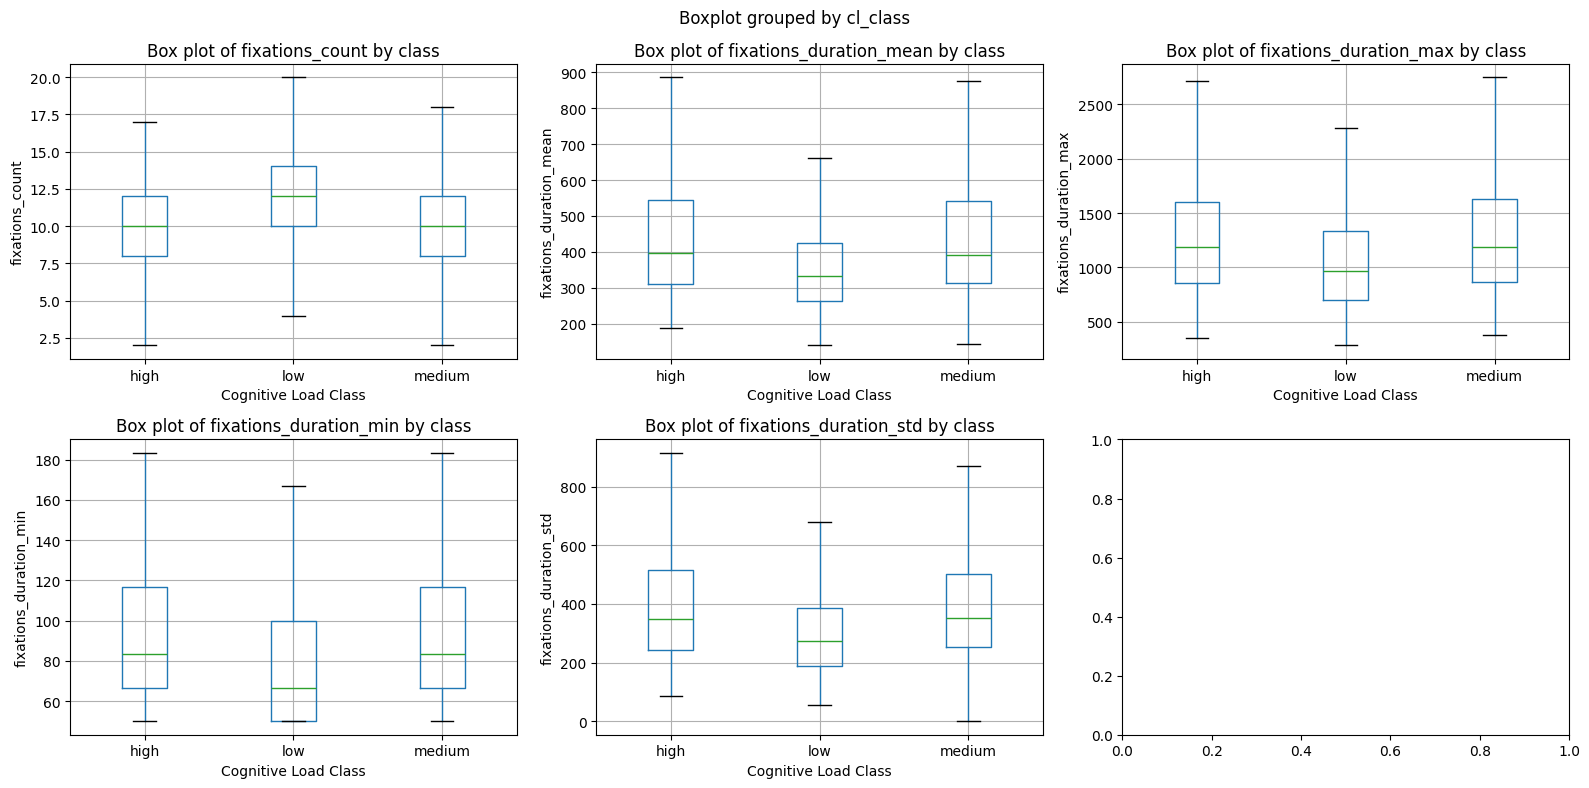

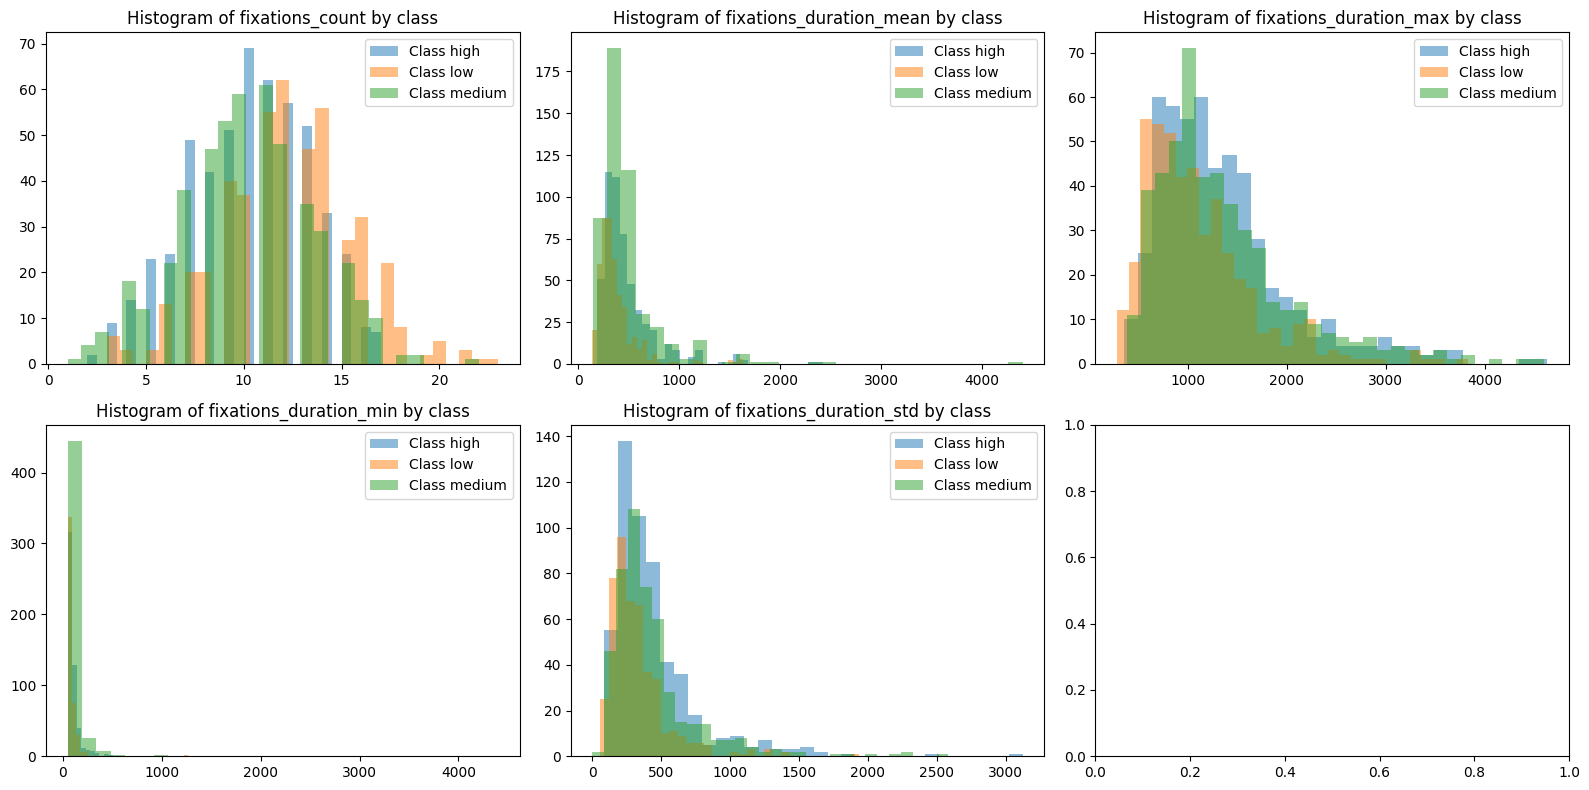

In [21]:
fixation_cols = [col for col in features_df.columns if col.startswith('fixations_')]
# Box plot for all fixation features by class
fig, axs = plt.subplots(2, len(fixation_cols) // 2 + 1, figsize=(16, 8), tight_layout=True)
axs = axs.flatten()
for i, col in enumerate(fixation_cols):
    features_df.boxplot(column=col, by='cl_class', ax=axs[i], ylabel=col, xlabel='Cognitive Load Class', showfliers=False)
    axs[i].set_title(f'Box plot of {col} by class')

# Also plot histograms of the fixation features by class
fig, axs = plt.subplots(2, len(fixation_cols) // 2 + 1, figsize=(16, 8), tight_layout=True)
axs = axs.flatten()
for i, col in enumerate(fixation_cols):
    for cl_class, group in features_df.groupby('cl_class'):
        axs[i].hist(group[col], bins=30, alpha=0.5, label=f'Class {cl_class}')
    axs[i].set_title(f'Histogram of {col} by class')
    axs[i].legend()

#### Saccades distributions

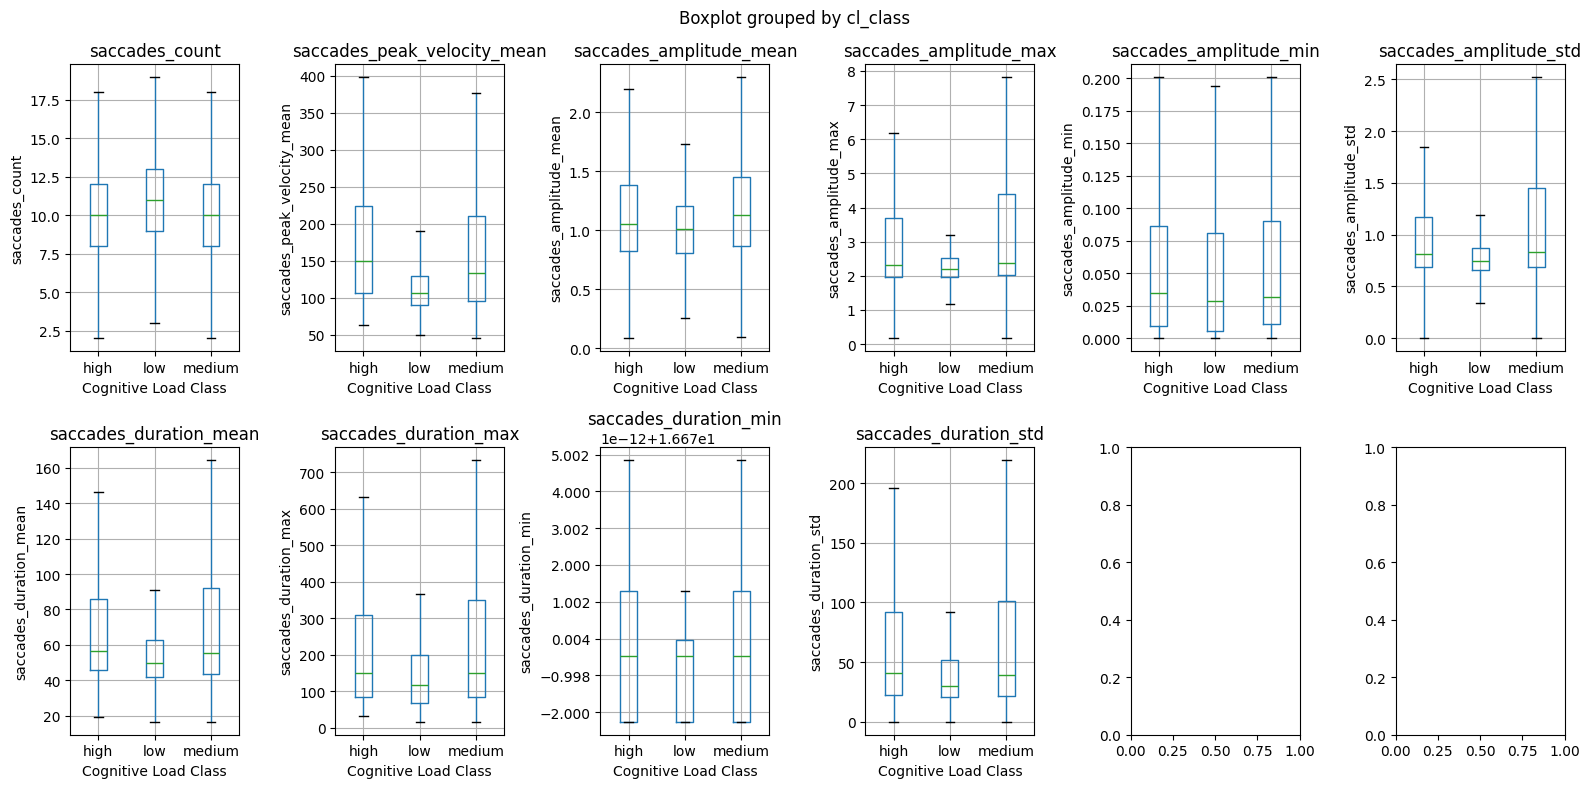

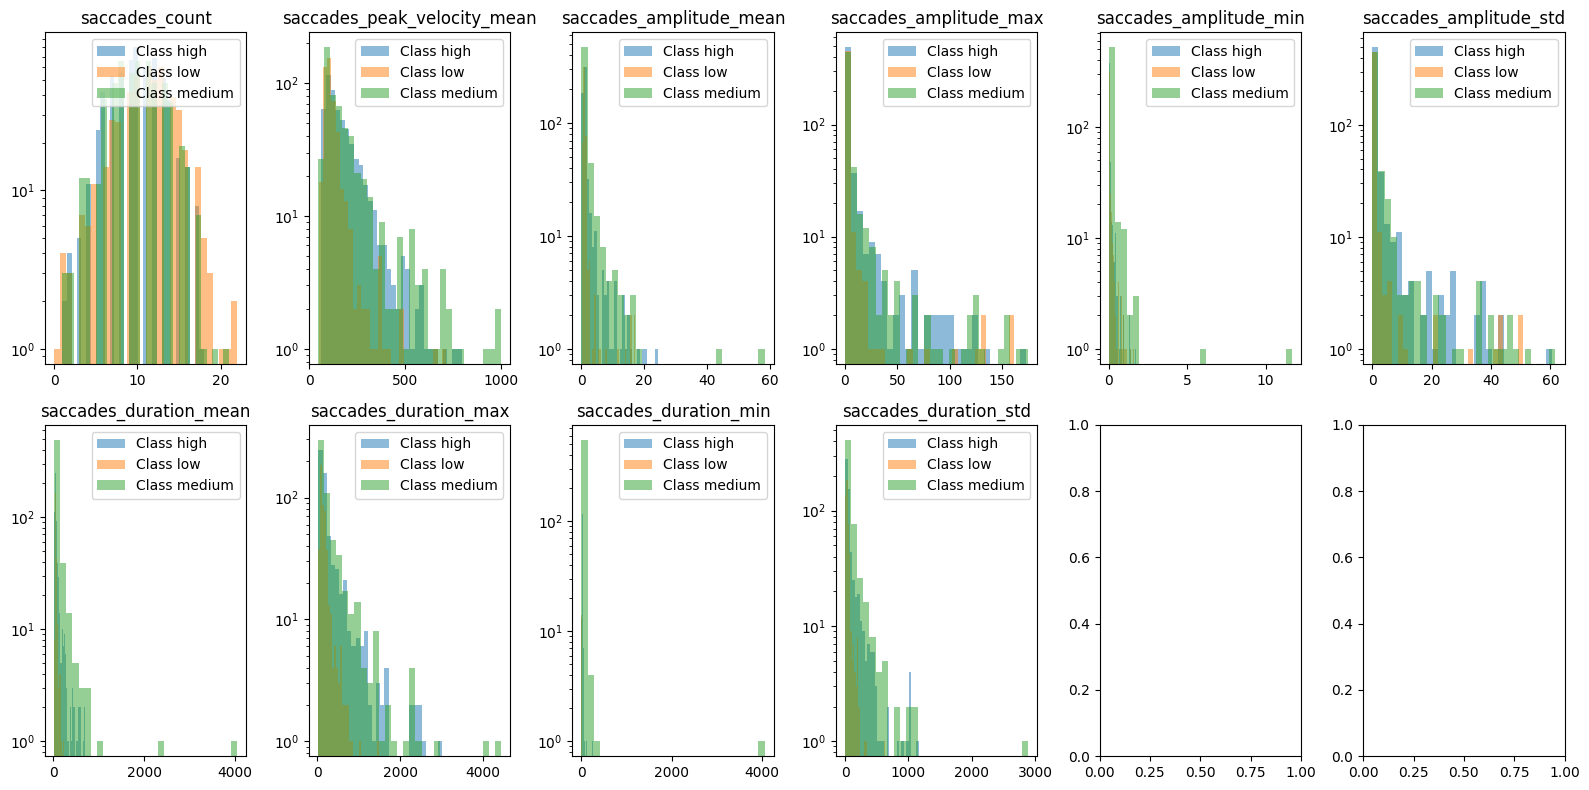

In [72]:
fixation_cols = [col for col in features_df.columns if col.startswith('saccades_')]
# Box plot for all fixation features by class
fig, axs = plt.subplots(2, len(fixation_cols) // 2 + 1, figsize=(16, 8), tight_layout=True)
axs = axs.flatten()
for i, col in enumerate(fixation_cols):
    features_df.boxplot(column=col, by='cl_class', ax=axs[i], ylabel=col, xlabel='Cognitive Load Class', showfliers=False)
    axs[i].set_title(f'{col}')

# Also plot histograms of the fixation features by class
fig, axs = plt.subplots(2, len(fixation_cols) // 2 + 1, figsize=(16, 8), tight_layout=True)
axs = axs.flatten()
for i, col in enumerate(fixation_cols):
    for cl_class, group in features_df.groupby('cl_class'):
        axs[i].hist(group[col], bins=30, alpha=0.5, label=f'Class {cl_class}', log=True)
    axs[i].set_title(f'{col}')
    axs[i].legend()

In [69]:
features_df_transformed.loc[features_df_transformed['fixations_duration_max'] > 1000, ['subject_id', 'task_id', 'fixations_duration_max']].sort_values(by='fixations_duration_max', ascending=False).head(10)

,subject_id,task_id,fixations_duration_max
1058,32,1,4617.59
1056,32,1,4467.56
67,3,1,4317.53
384,12,4,3967.46
1422,41,4,3684.07
496,14,4,3584.05
1370,41,1,3384.01
1065,32,1,3367.34
74,3,2,3334.00
1053,32,1,3283.99


In [78]:
features_df_transformed.loc[features_df_transformed['saccades_duration_max'] > 1000, ['subject_id', 'task_id']].value_counts()

subject_id  task_id
21          4          7
44          4          5
17          4          4
30          4          4
13          3          3
24          3          3
            4          3
25          3          3
36          3          3
5           4          2
14          4          2
15          4          2
20          3          2
28          4          2
31          4          2
40          3          2
            4          2
44          3          2
47          3          2
1           3          1
2           3          1
            4          1
3           4          1
9           3          1
11          4          1
12          4          1
17          3          1
19          3          1
20          4          1
27          3          1
29          4          1
36          4          1
37          4          1
43          3          1
46          3          1
            4          1
Name: count, dtype: int64

### TEMP

In [50]:
from sklearn import preprocessing
# z-normalize features
features_df_transformed = features_df.copy()
features_df_transformed.dropna(inplace=True) # Drop rows with NaNs for now
# features_df_transformed.drop(columns=['pupil_ripa2'], inplace=True)
feature_cols = [col for col in features_df_transformed.columns if col not in ['subject_id', 'task_id', 'cl_class']]
# feature_cols = ['pupil_lhipa', 'pupil_ripa2', 'fixations_count', 'saccades_count']

features_df_transformed.describe()

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_std,saccades_count,saccades_peak_velocity_mean,saccades_amplitude_mean,saccades_amplitude_max,saccades_amplitude_min,...,saccades_duration_max,saccades_duration_min,saccades_duration_std,blinks_count,blinks_duration_mean,pupil_lhipa,pupil_ripa2,bad_samples_ratio,subject_id,task_id
count,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,...,3974.000000,3974.000000,3.974000e+03,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000,3974.000000
mean,17.173880,446.244191,1597.618571,82.020259,440.013003,16.438349,120.298506,1.434644,5.596758,0.062091,...,194.893022,17.156593,4.875972e+01,1.635883,0.088296,4.475027,0.004187,5.853397,24.825365,2.745596
std,5.004072,226.544361,800.105524,68.224897,283.846246,5.050024,48.368240,1.243098,9.141651,0.156849,...,171.408384,5.200141,4.749996e+01,2.145484,0.080740,0.535244,0.004089,7.052271,13.492312,1.092016
min,3.000000,150.030000,300.060000,50.010000,59.487506,2.000000,54.562457,0.148159,0.242453,0.000000,...,16.670000,0.000000,1.025581e-12,0.000000,0.000000,2.047783,0.000269,0.000000,1.000000,1.000000
25%,14.000000,314.348571,1050.210000,50.010000,266.882840,13.000000,96.622999,0.998406,2.388554,0.003439,...,83.350000,16.670000,2.227960e+01,0.000000,0.000000,4.207575,0.001862,0.800000,13.000000,2.000000
50%,17.000000,392.671111,1416.950000,66.680000,368.594019,16.000000,110.438461,1.238226,3.910478,0.020861,...,150.030000,16.670000,3.401512e+01,1.000000,0.111133,4.568225,0.003237,2.800000,24.000000,3.000000
75%,20.000000,509.774554,1917.050000,83.350000,517.879942,20.000000,128.920509,1.623431,6.347433,0.053500,...,233.380000,16.670000,5.603682e+01,2.000000,0.155587,4.808658,0.005213,8.400000,38.000000,4.000000
max,35.000000,2733.880000,7884.910000,1833.700000,4494.886551,35.000000,637.822732,40.698850,179.619463,2.062723,...,2117.090000,66.680000,6.463528e+02,12.000000,0.283390,5.770389,0.065794,30.000000,47.000000,4.000000


In [51]:
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn import svm, ensemble

features_df_transformed['labels'] = features_df_transformed['cl_class'].map({'low': 0, 'medium': 1, 'high': 2})

X = features_df_transformed[feature_cols].values
y = features_df_transformed['labels'].values

scaler = preprocessing.StandardScaler()
# scaler = preprocessing.MinMaxScaler()
scaler.fit(X)

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
# Use cross-validation to create a validation set from the training set
cv = ShuffleSplit(n_splits=5, test_size=0.25, random_state=42)

print(f"Training set size: {len(train_x)}, Test set size: {len(test_x)}")

train_x_transformed = scaler.transform(train_x)
model = svm.LinearSVC()
# model = ensemble.RandomForestClassifier(n_estimators=100, random_state=42)
score = cross_val_score(model, train_x_transformed, train_y, cv=cv)
model.fit(train_x_transformed, train_y)
train_acc = model.score(train_x_transformed, train_y)
print(f"Train Accuracy: {train_acc:.2f}, Cross-validation Score: {score.mean():.2f} (+/- {score.std() * 2:.2f})")
print("SVC coeffs classes:")
# coeffs = [pd.Series(model.coef_[i], index=feature_cols).sort_values(ascending=False) for i in range(len(model.coef_))]
# coeffs_df = pd.DataFrame({f'class_{i}': coeffs[i] for i in range(len(model.coef_))})
# display(coeffs_df)

Training set size: 3179, Test set size: 795
Train Accuracy: 0.52, Cross-validation Score: 0.51 (+/- 0.02)
SVC coeffs classes:


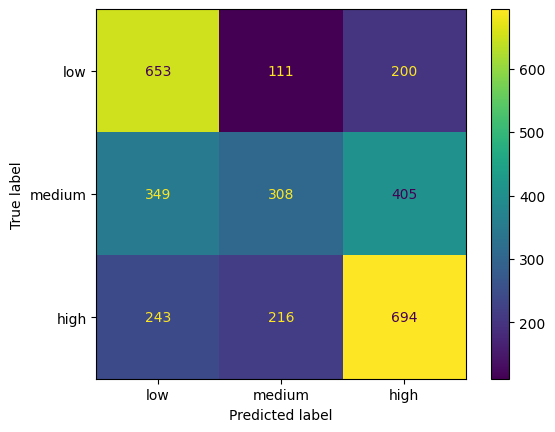

In [52]:
# Lets show the confusion matrix for the 3 classes (on validation set)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

val_y_pred = model.predict(train_x_transformed)
cm = confusion_matrix(train_y, val_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'medium', 'high'])
disp.plot()